In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist



In [26]:
(x_train, y_train), (x_test, y_test) = mnist.load_data() #mnist - hand drawn numbers
x_train = x_train / 255.0
y_train = y_train / 255.0

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras import Input
model = Sequential( [ #Sequential model - layers stacked one after the other
    Input(shape=(28,28)), 
    Flatten(), #each 28x28 pixel image turned into a 1D array
    Dense(128, activation = 'relu'), 
    #fully connected hidden layer (dense) with 128 neurons 
    ReLU - activation function that introduces nonlinearity
    Dense(10, activation = 'softmax') ])  #output layer with 10 neurons (0-9)
    #converts a vector of 10 real numbers into a probability distribution of 10 possible outcomes


In [23]:
model.compile(optimizer = 'adam', #compile and train!
              #adam - fast, effective optimizatioln algorithm that adapts learning rates during training
              loss = 'sparse_categorical_crossentropy', 
              #how to measure error - loss function for multi-class classification
              metrics=['accuracy']) #tells Keras to report accuracy in training and evaluation
model.fit(x_train, y_train, epochs = 5, validation_split = 0.1) #entire training five times - epoch 5
#validation split - 10% of training data as validation set to see how well it is generalizing (not memorizing)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9440 - loss: 0.2526 - val_accuracy: 0.9415 - val_loss: 0.2173
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9501 - loss: 0.2082 - val_accuracy: 0.9530 - val_loss: 0.2366
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9519 - loss: 0.1937 - val_accuracy: 0.9572 - val_loss: 0.2006
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9527 - loss: 0.1880 - val_accuracy: 0.9542 - val_loss: 0.1936
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9568 - loss: 0.1724 - val_accuracy: 0.9530 - val_loss: 0.1944


In [32]:
test_loss, test_acc=model.evaluate(x_test, y_test) #evaluates the trained neural network on test dataset
#neural network has never seen this data before!
print("Accuracy =", test_acc, ", Yippee!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9398 - loss: 0.2995
Accuracy = 0.9460999965667725 , Yippee!


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


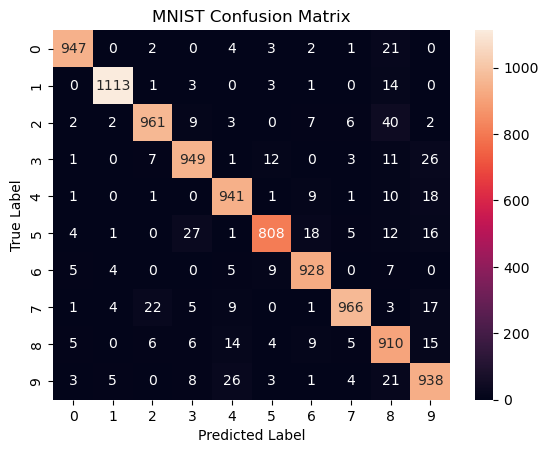

In [38]:
plt.close()
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test).argmax(axis=1) #2D array of probabilities
#argmax axis =1 picks index of highest probability

cm = confusion_matrix(y_test, y_pred) #10x10 matrix where rows are actual labels, columns are predicted
sns.heatmap(cm, annot=True, fmt = 'd')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('MNIST Confusion Matrix')
plt.show()
plt.close()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


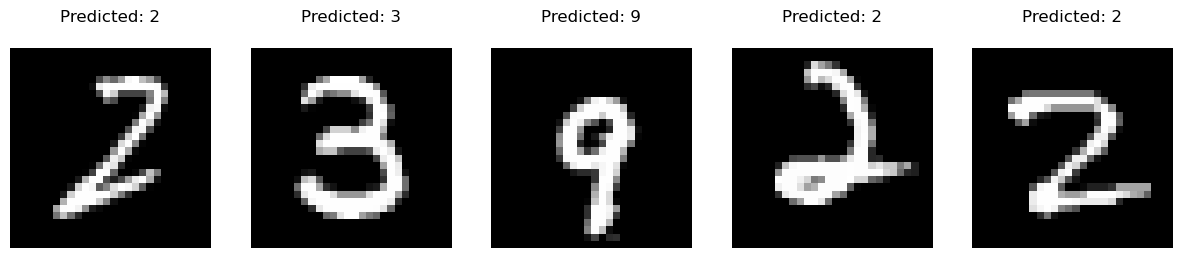

Examples of numbers, and predictions!


In [78]:
plt.close()
random_index = np.random.choice(len(x_test), 5, replace = False)

predictions = model.predict(x_test[random_index])
predicted_labels = np.argmax(predictions, axis = 1)

plt.figure(figsize = (15,3))

for i, idx in enumerate(random_index):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[idx], cmap = 'grey')
    plt.title(f"Predicted: {predicted_labels[i]}\n")
    plt.axis('off')
plt.show()
plt.close()
print("Examples of numbers, and predictions!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


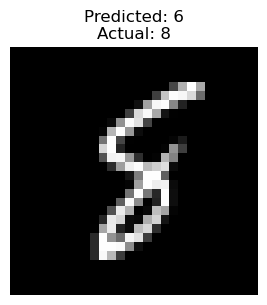

Examples of incorrect predictions!


In [80]:
plt.close()
# Pick more samples up front in case most are correct
random_index = np.random.choice(len(x_test), 30, replace=False)

# Predict on selected samples
predictions = model.predict(x_test[random_index])
predicted_labels = np.argmax(predictions, axis=1)

# Filter incorrect predictions
incorrect_indices = [i for i, idx in enumerate(random_index) if predicted_labels[i] != y_test[idx]]

# Limit to 5 incorrect samples max
incorrect_indices = incorrect_indices[:5]

plt.figure(figsize=(15, 3))

for i, wrong_i in enumerate(incorrect_indices):
    idx = random_index[wrong_i]
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Predicted: {predicted_labels[wrong_i]}\nActual: {y_test[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()
plt.close()
print("Examples of incorrect predictions!")
